In [1]:
# Connect with Google Drive
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Import required libraries
import numpy as np
import pandas as pd

In [3]:
# Set processed data path
processed_data_path = "/content/drive/MyDrive/Credit-Card-Fraud-Detection/processed_data/"

In [4]:
# Load GRU input data
X_train_seq = np.load(processed_data_path + "X_train_seq.npy")
X_val_seq = np.load(processed_data_path + "X_val_seq.npy")
X_test_seq = np.load(processed_data_path + "X_test_seq.npy")

In [5]:
# Load target labels
y_train = pd.read_csv(processed_data_path + "y_train.csv").values.ravel()
y_val = pd.read_csv(processed_data_path + "y_val.csv").values.ravel()
y_test = pd.read_csv(processed_data_path + "y_test.csv").values.ravel()

In [6]:
# Check data shapes
print("X_train_seq shape:", X_train_seq.shape)
print("X_val_seq shape:", X_val_seq.shape)
print("X_test_seq shape:", X_test_seq.shape)

print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)
print("y_test shape:", y_test.shape)

X_train_seq shape: (184421, 30, 1)
X_val_seq shape: (42559, 30, 1)
X_test_seq shape: (56746, 30, 1)
y_train shape: (184421,)
y_val shape: (42559,)
y_test shape: (56746,)


In [7]:
# Check data types
print("X_train_seq dtype:", X_train_seq.dtype)
print("y_train dtype:", y_train.dtype)

# Check missing values
print("Missing values in X_train_seq:", np.isnan(X_train_seq).sum())
print("Missing values in y_train:", np.isnan(y_train).sum())

X_train_seq dtype: float64
y_train dtype: int64
Missing values in X_train_seq: 0
Missing values in y_train: 0


In [8]:
# Check class distribution
print("Training class distribution:")
print(pd.Series(y_train).value_counts())

print("\nValidation class distribution:")
print(pd.Series(y_val).value_counts())

print("\nTest class distribution:")
print(pd.Series(y_test).value_counts())

Training class distribution:
0    184114
1       307
Name: count, dtype: int64

Validation class distribution:
0    42488
1       71
Name: count, dtype: int64

Test class distribution:
0    56651
1       95
Name: count, dtype: int64


In [9]:
# Check unique target labels
print("Unique labels:", np.unique(y_train))

Unique labels: [0 1]


In [10]:
# Install TensorFlow
#!pip install tensorflow

In [11]:
# Import TensorFlow libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout

In [12]:
# Check TensorFlow version
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [13]:
# Import GRU model layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, GRU, Dense, Dropout

In [14]:
# Build the GRU model
model = Sequential([
    Input(shape=(30, 1)),
    GRU(64),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

In [15]:
# Display model architecture
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,977 (58.50 KB)

 Trainable params: 14,977 (58.50 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# Compile the GRU model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [17]:
# Check model configuration
print("Model compiled successfully.")

Model compiled successfully.


In [18]:
# Import class weight utility
from sklearn.utils.class_weight import compute_class_weight

In [19]:
# Calculate class weights
classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weight_dict = dict(zip(classes, class_weights))

print("Class weights:", class_weight_dict)

Class weights: {np.int64(0): np.float64(0.5008337225849202), np.int64(1): np.float64(300.3599348534202)}


In [20]:
# Train the GRU model
history = model.fit(
    X_train_seq,
    y_train,
    validation_data=(X_val_seq, y_val),
    epochs=10,
    batch_size=256,
    class_weight=class_weight_dict
)

Epoch 1/10
721/721 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.8859 - loss: 0.3790 - val_accuracy: 0.9773 - val_loss: 0.1201
Epoch 2/10
721/721 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9556 - loss: 0.2490 - val_accuracy: 0.9814 - val_loss: 0.2273
Epoch 3/10
721/721 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9577 - loss: 0.2343 - val_accuracy: 0.9782 - val_loss: 0.2290
Epoch 4/10
721/721 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9668 - loss: 0.2317 - val_accuracy: 0.8707 - val_loss: 0.4237
Epoch 5/10
721/721 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9603 - loss: 0.2086 - val_accuracy: 0.9929 - val_loss: 0.1407
Epoch 6/10
721/721 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9768 - loss: 0.2058 - val_accuracy: 0.9798 - val_loss: 0.1730
Epoch 7/10
721/721 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9672 - loss: 0.2041 - val_accuracy: 0.9701 - val_loss: 0.1797
Epoch 8/10
721/721 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9726 - loss: 0.1937 - val_accuracy: 0

In [21]:
# Import plotting library
import matplotlib.pyplot as plt

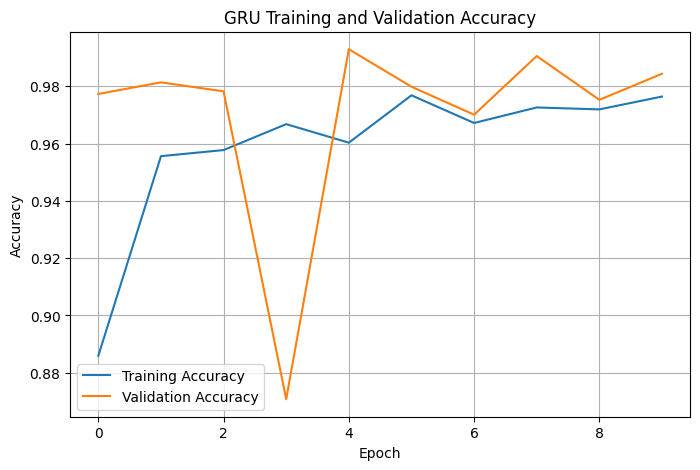

In [22]:
# Plot training and validation accuracy
plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('GRU Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()

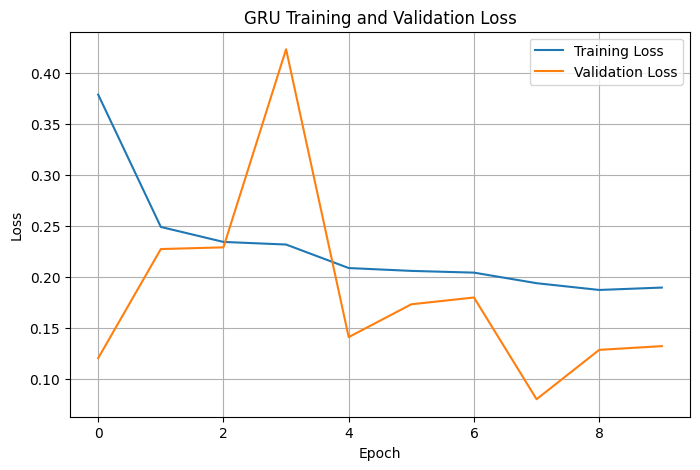

In [23]:
# Plot training and validation loss
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('GRU Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

In [24]:
# Set figure output path
figure_path = "/content/drive/MyDrive/Credit-Card-Fraud-Detection/results/figures/"

In [25]:
# Evaluate the GRU model on test data
test_loss, test_accuracy = model.evaluate(
    X_test_seq,
    y_test,
    verbose=1
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

1774/1774 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9829 - loss: 0.1340
Test Loss: 0.1340198814868927
Test Accuracy: 0.9828886389732361


In [26]:
# Generate predictions on test data
y_pred_prob = model.predict(X_test_seq)

print("Prediction shape:", y_pred_prob.shape)

1774/1774 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step
Prediction shape: (56746, 1)


In [27]:
# Convert probabilities to binary predictions
y_pred = (y_pred_prob >= 0.5).astype(int).ravel()

print("Predicted labels:", np.unique(y_pred))

Predicted labels: [0 1]


In [28]:
# Import evaluation metrics
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [29]:
# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[55696   955]
 [   16    79]]


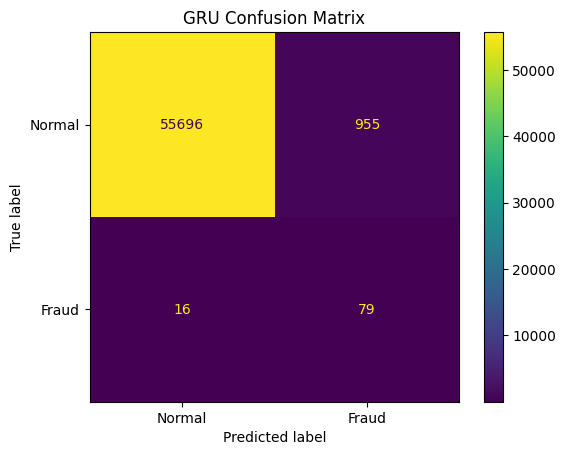

In [30]:
# Plot confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Normal', 'Fraud']
)

disp.plot()
plt.title('GRU Confusion Matrix')
plt.show()

In [31]:
# Import evaluation metrics
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report
)

In [32]:
# Calculate precision, recall and F1-score
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Precision: 0.07640232108317214
Recall: 0.8315789473684211
F1-score: 0.13994685562444642


In [33]:
# Calculate ROC-AUC and PR-AUC
roc_auc = roc_auc_score(y_test, y_pred_prob.ravel())
pr_auc = average_precision_score(y_test, y_pred_prob.ravel())

print("ROC-AUC:", roc_auc)
print("PR-AUC:", pr_auc)

ROC-AUC: 0.9531842704500038
PR-AUC: 0.6646560170297685


In [34]:
# Generate classification report
print("Classification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=['Normal', 'Fraud']
    )
)

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.98      0.99     56651
       Fraud       0.08      0.83      0.14        95

    accuracy                           0.98     56746
   macro avg       0.54      0.91      0.57     56746
weighted avg       1.00      0.98      0.99     56746



In [37]:
# Import os
import os

In [38]:
# Create models folder
model_folder = "/content/drive/MyDrive/Credit-Card-Fraud-Detection/models/"

os.makedirs(model_folder, exist_ok=True)

print("Models folder is ready.")

Models folder is ready.


In [39]:
# Set model output path
model_path = model_folder + "gru_model.keras"

In [40]:
# Save the trained GRU model
model.save(model_path)

print("GRU model saved successfully.")
print("Saved to:", model_path)

GRU model saved successfully.
Saved to: /content/drive/MyDrive/Credit-Card-Fraud-Detection/models/gru_model.keras


In [41]:
# Create result folders
figures_path = "/content/drive/MyDrive/Credit-Card-Fraud-Detection/results/figures/"
tables_path = "/content/drive/MyDrive/Credit-Card-Fraud-Detection/results/tables/"

os.makedirs(figures_path, exist_ok=True)
os.makedirs(tables_path, exist_ok=True)

print("Result folders are ready.")

Result folders are ready.


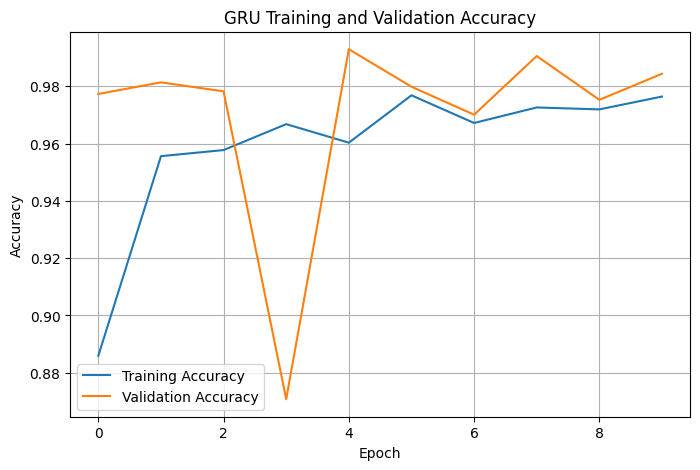

Accuracy graph saved successfully.


In [42]:
# Plot and save accuracy graph
plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('GRU Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.savefig(
    figures_path + "gru_accuracy.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("Accuracy graph saved successfully.")

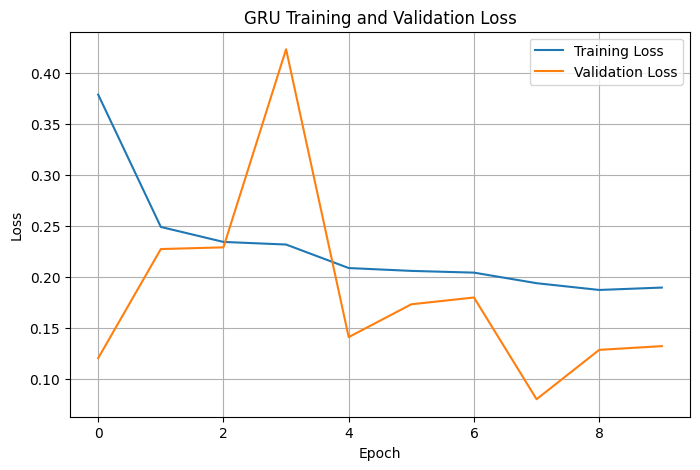

Loss graph saved successfully.


In [43]:
# Plot and save loss graph
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('GRU Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.savefig(
    figures_path + "gru_loss.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("Loss graph saved successfully.")

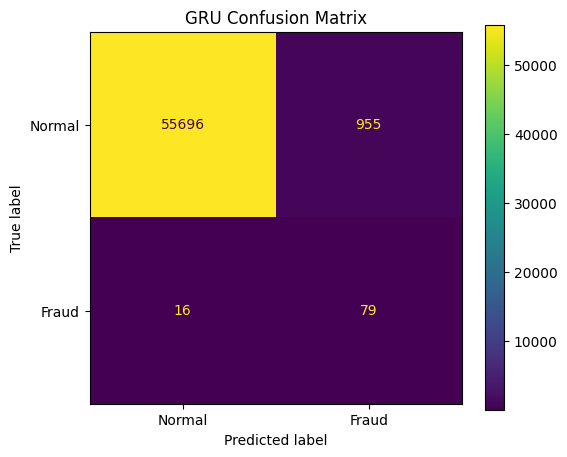

Confusion matrix saved successfully.


In [44]:
# Plot and save confusion matrix
plt.figure(figsize=(6, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Normal', 'Fraud']
)

disp.plot(ax=plt.gca())

plt.title('GRU Confusion Matrix')

plt.savefig(
    figures_path + "gru_confusion_matrix.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("Confusion matrix saved successfully.")

In [45]:
# Create GRU results table
results = pd.DataFrame({
    'Metric': [
        'Test Loss',
        'Test Accuracy',
        'Precision',
        'Recall',
        'F1-score',
        'ROC-AUC',
        'PR-AUC'
    ],
    'Value': [
        test_loss,
        test_accuracy,
        precision,
        recall,
        f1,
        roc_auc,
        pr_auc
    ]
})

# Save results table
results.to_csv(
    tables_path + "gru_results.csv",
    index=False
)

print("GRU results table saved successfully.")
print(results)

GRU results table saved successfully.
          Metric     Value
0      Test Loss  0.134020
1  Test Accuracy  0.982889
2      Precision  0.076402
3         Recall  0.831579
4       F1-score  0.139947
5        ROC-AUC  0.953184
6         PR-AUC  0.664656


In [46]:
# Create confusion matrix table
cm_results = pd.DataFrame({
    'Metric': [
        'True Negative',
        'False Positive',
        'False Negative',
        'True Positive'
    ],
    'Value': [
        cm[0, 0],
        cm[0, 1],
        cm[1, 0],
        cm[1, 1]
    ]
})

# Save confusion matrix table
cm_results.to_csv(
    tables_path + "gru_confusion_matrix.csv",
    index=False
)

print("Confusion matrix table saved successfully.")
print(cm_results)

Confusion matrix table saved successfully.
           Metric  Value
0   True Negative  55696
1  False Positive    955
2  False Negative     16
3   True Positive     79


In [47]:
# Import ROC curve function
from sklearn.metrics import roc_curve

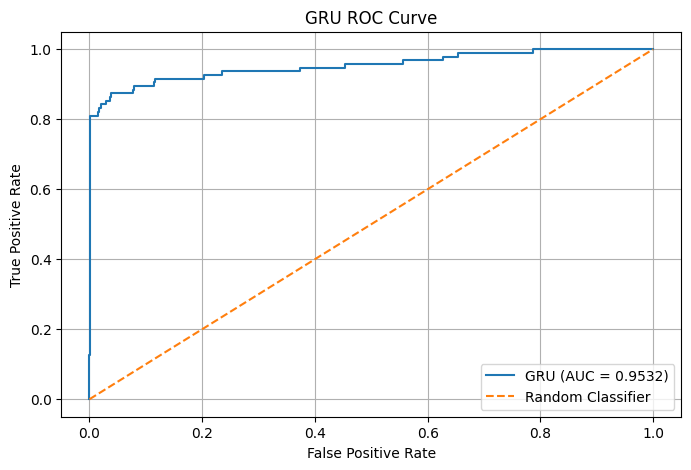

ROC curve saved successfully.


In [48]:
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob.ravel())

# Plot ROC curve
plt.figure(figsize=(8, 5))

plt.plot(
    fpr,
    tpr,
    label=f'GRU (AUC = {roc_auc:.4f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)

plt.title('GRU ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)

# Save ROC curve
plt.savefig(
    figures_path + "gru_roc_curve.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("ROC curve saved successfully.")

In [49]:
# Import Precision-Recall curve function
from sklearn.metrics import precision_recall_curve

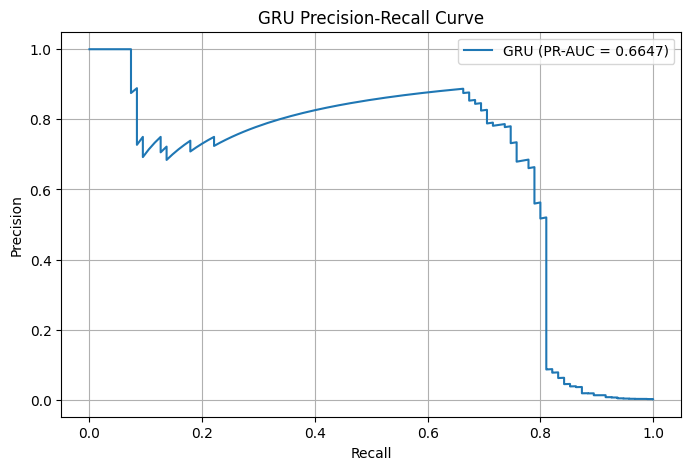

Precision-Recall curve saved successfully.


In [50]:
# Calculate Precision-Recall curve
pr_precision, pr_recall, pr_thresholds = precision_recall_curve(
    y_test,
    y_pred_prob.ravel()
)

# Plot Precision-Recall curve
plt.figure(figsize=(8, 5))

plt.plot(
    pr_recall,
    pr_precision,
    label=f'GRU (PR-AUC = {pr_auc:.4f})'
)

plt.title('GRU Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.grid(True)

# Save Precision-Recall curve
plt.savefig(
    figures_path + "gru_precision_recall_curve.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("Precision-Recall curve saved successfully.")

In [51]:
# Create classification report
report = classification_report(
    y_test,
    y_pred,
    target_names=['Normal', 'Fraud'],
    output_dict=True
)

# Convert report to DataFrame
report_df = pd.DataFrame(report).transpose()

# Save classification report
report_df.to_csv(
    tables_path + "gru_classification_report.csv"
)

print("Classification report saved successfully.")
print(report_df)

Classification report saved successfully.
              precision    recall  f1-score       support
Normal         0.999713  0.983142  0.991358  56651.000000
Fraud          0.076402  0.831579  0.139947     95.000000
accuracy       0.982889  0.982889  0.982889      0.982889
macro avg      0.538058  0.907361  0.565653  56746.000000
weighted avg   0.998167  0.982889  0.989933  56746.000000
